# Test Audio Loading Across Packages

Quick sanity-check notebook: run each package's loader once, look at the
resulting tensor shape/dtype, waveform values, and duration -- before
running the full RTF/CPU/memory profiling scripts.

Set `AUDIO_PATH` below to your test file, then run all cells.

In [1]:
AUDIO_PATH = "../data/Molavi.wav"
TARGET_SR = 16000

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_waveform(tensor, title):
    y = tensor.squeeze().numpy()
    plt.figure(figsize=(10, 2.5))
    plt.plot(y)
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def report(name, tensor, duration):
    print(f"--- {name} ---")
    print(f"shape: {tuple(tensor.shape)}")
    print(f"dtype: {tensor.dtype}")
    print(f"duration (s): {duration:.4f}")
    print(f"min/max/mean: {tensor.min().item():.4f} / {tensor.max().item():.4f} / {tensor.mean().item():.4f}")
    plot_waveform(tensor, name)

## librosa

--- librosa ---
shape: (1, 207360)
dtype: torch.float32
duration (s): 12.9600
min/max/mean: -0.6875 / 0.3538 / 0.0000


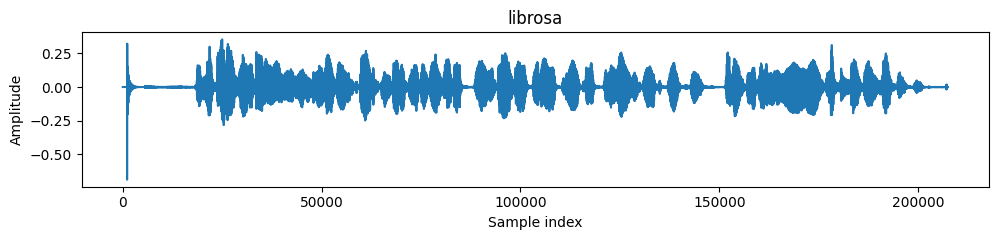

In [6]:
def load_librosa(path):
    import librosa
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    return torch.from_numpy(y).unsqueeze(0)

def duration_librosa(path):
    import librosa
    try:
        return librosa.get_duration(path=path)
    except TypeError:
        return librosa.get_duration(filename=path)

t_librosa = load_librosa(AUDIO_PATH)
d_librosa = duration_librosa(AUDIO_PATH)
report("librosa", t_librosa, d_librosa)

## soundfile

--- soundfile ---
shape: (1, 207360)
dtype: torch.float32
duration (s): 12.9600
min/max/mean: -0.7320 / 0.3530 / 0.0000


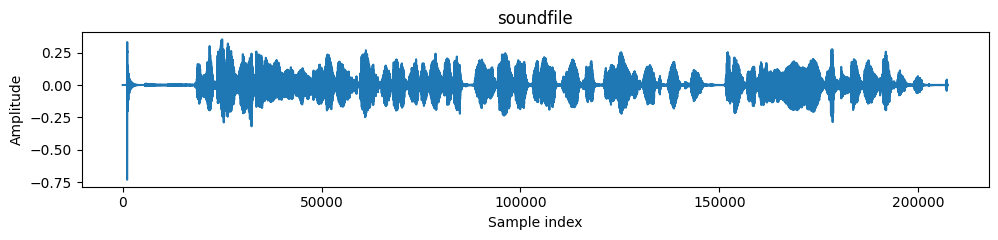

In [7]:
def load_soundfile(path):
    import soundfile as sf
    data, orig_sr = sf.read(path)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if orig_sr != TARGET_SR:
        target_length = int(len(data) * TARGET_SR / orig_sr)
        original_indices = np.linspace(0, len(data) - 1, num=len(data))
        target_indices = np.linspace(0, len(data) - 1, num=target_length)
        data = np.interp(target_indices, original_indices, data)
    return torch.from_numpy(data.astype(np.float32)).unsqueeze(0)

def duration_soundfile(path):
    import soundfile as sf
    info = sf.info(path)
    return info.frames / info.samplerate

t_soundfile = load_soundfile(AUDIO_PATH)
d_soundfile = duration_soundfile(AUDIO_PATH)
report("soundfile", t_soundfile, d_soundfile)

## torchaudio

--- torchaudio ---
shape: (1, 207360)
dtype: torch.float32
duration (s): 12.9600
min/max/mean: -0.6904 / 0.3540 / 0.0000


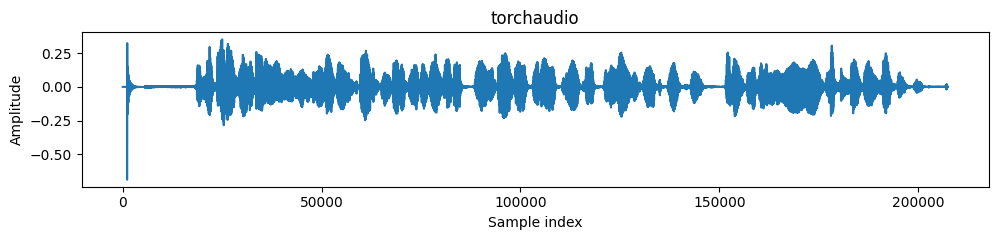

In [8]:
def load_torchaudio(path):
    import torchaudio
    import torchaudio.transforms as T
    waveform, orig_sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if orig_sr != TARGET_SR:
        waveform = T.Resample(orig_sr, TARGET_SR)(waveform)
    return waveform

def duration_torchaudio(path):
    import torchaudio
    info = torchaudio.info(path)
    return info.num_frames / info.sample_rate

t_torchaudio = load_torchaudio(AUDIO_PATH)
d_torchaudio = duration_torchaudio(AUDIO_PATH)
report("torchaudio", t_torchaudio, d_torchaudio)

## scipy

--- scipy ---
shape: (1, 207360)
dtype: torch.float32
duration (s): 12.9600
min/max/mean: -0.6892 / 0.3561 / 0.0000


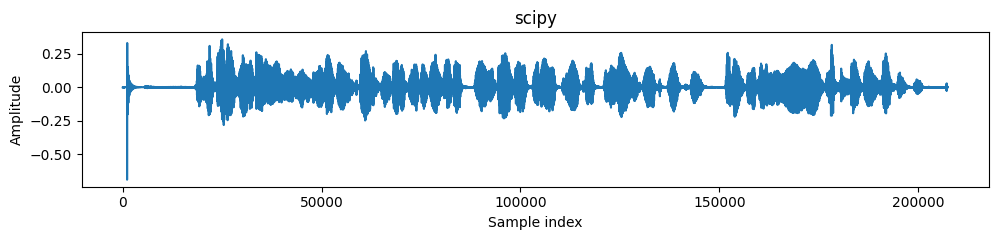

In [28]:
def load_scipy(path):
    from scipy.io import wavfile
    from scipy.signal import resample
    orig_sr, data = wavfile.read(path)
    data = data.astype(np.float32) / np.iinfo(data.dtype).max if np.issubdtype(data.dtype, np.integer) else data.astype(np.float32)

    if data.ndim > 1:
        data = data.mean(axis=1)
    if orig_sr != TARGET_SR:
        n_samples = int(len(data) * TARGET_SR / orig_sr)
        data = resample(data, n_samples)
    return torch.from_numpy(data.astype(np.float32)).unsqueeze(0)

def duration_scipy(path):
    from scipy.io import wavfile
    sr, data = wavfile.read(path)
    return len(data) / sr

t_scipy = load_scipy(AUDIO_PATH)
d_scipy = duration_scipy(AUDIO_PATH)
report("scipy", t_scipy, d_scipy)

## pydub

Requires `ffmpeg` installed on the system.

--- pydub ---
shape: (1, 207360)
dtype: torch.float32
duration (s): 12.9600
min/max/mean: -0.7320 / 0.3878 / 0.0000


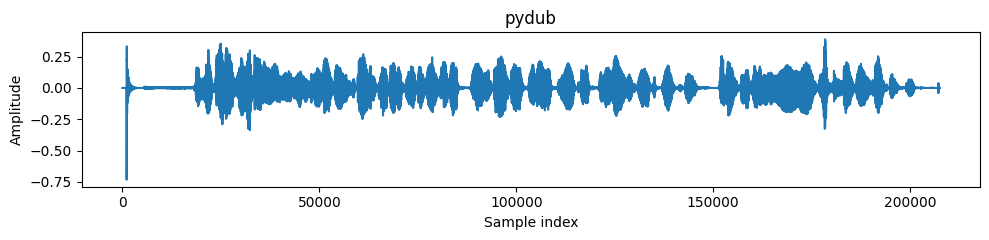

In [27]:
def load_pydub(path):
    from pydub import AudioSegment
    audio = AudioSegment.from_file(path).set_frame_rate(TARGET_SR).set_channels(1)
    samples = np.array(audio.get_array_of_samples()).astype(np.float32)
    max_val = float(1 << (8 * audio.sample_width - 1))  # e.g. 32768 for 16-bit
    samples = samples / max_val
    return torch.from_numpy(samples).unsqueeze(0)

def duration_pydub(path):
    from pydub import AudioSegment
    audio = AudioSegment.from_file(path)
    return len(audio) / 1000.0

t_pydub = load_pydub(AUDIO_PATH)
d_pydub = duration_pydub(AUDIO_PATH)
report("pydub", t_pydub, d_pydub)

## Side-by-side comparison

In [29]:
import pandas as pd

rows = []
for name, tensor, duration in [
    ("librosa", t_librosa, d_librosa),
    ("soundfile", t_soundfile, d_soundfile),
    ("torchaudio", t_torchaudio, d_torchaudio),
    ("scipy", t_scipy, d_scipy),
    ("pydub", t_pydub, d_pydub),
]:
    rows.append({
        "package": name,
        "shape": tuple(tensor.shape),
        "dtype": str(tensor.dtype),
        "duration_s": round(duration, 4),
        "min": round(tensor.min().item(), 4),
        "max": round(tensor.max().item(), 4),
        "mean": round(tensor.mean().item(), 6),
    })

pd.DataFrame(rows)

,package,shape,dtype,duration_s,min,max,mean
0,librosa,"(1, 207360)",torch.float32,12.96,-0.6875,0.3538,0.000002
1,soundfile,"(1, 207360)",torch.float32,12.96,-0.7320,0.3530,0.000002
2,torchaudio,"(1, 207360)",torch.float32,12.96,-0.6904,0.3540,0.000002
3,scipy,"(1, 207360)",torch.float32,12.96,-0.6892,0.3561,0.000002
4,pydub,"(1, 207360)",torch.float32,12.96,-0.7320,0.3878,0.000002


**What to check here:**
- All `shape`s should be `(1, N)` with roughly the same `N` across packages
  (small differences are expected/normal -- resampling rounding differs slightly
  between an FFT-based resampler like scipy/librosa and linear interpolation).
- All `dtype`s should be `torch.float32`.
- `min`/`max` ranges wildly different (e.g. one in `[-1, 1]` and another in
  `[-32768, 32767]`) means one package didn't get amplitude-normalized --
  worth checking before trusting the profiling numbers.